In [61]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src.constants import (
    INSAMPLE_END, BACKTEST_START, BACKTEST_END, SIGNAL_HORIZON_DAYS,
)

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

# --- Load data ---
raw = pd.read_parquet('../data/funding_rates.parquet')
raw.index = raw.index.floor('h')
funding_all = raw[~raw.index.duplicated(keep='last')].sort_index()

prices_all = pd.read_parquet('../data/prices.parquet')

# Betas estimated on in-sample data only (notebook 01)
betas = pd.read_parquet('../data/coin_betas.parquet').astype(float)

# Restrict universe to coins with valid betas
valid = [c for c in betas.index if c in funding_all.columns and c in prices_all.columns
         and betas.loc[c, 'beta'] > 0 and betas.loc[c, 'idio_vol'] > 0]
funding_all = funding_all[valid]
prices_all  = prices_all[valid]
betas       = betas.loc[valid]

print(f'Universe: {len(valid)} coins — {valid}')
print(f'Backtest window: {BACKTEST_START.date()} → {BACKTEST_END.date()}')

Universe: 15 coins — ['BNB', 'BTC', 'XRP', 'ETH', 'APE', 'LINK', 'AAVE', 'SOL', 'ADA', 'ZRO', 'DOGE', 'ARB', 'SUI', 'TAO', 'LDO']
Backtest window: 2025-09-01 → 2026-04-29


## 1. Signal (OOS)

Apply the calibrated EWMA to the full history (rolling — no lookahead), then take the OOS slice.
Dividing by in-sample `idio_vol` gives a risk-adjusted funding yield: coins with high expected
funding per unit of idiosyncratic risk are candidates to short; low-ratio coins are candidates to long.

`BEST_HL` should match the best half-life found in `03_signal_research.ipynb`.

In [62]:
BEST_HLS    = [168, 72]        # top-2 EWMA half-lives from signal research (notebook 03)
ROLL_WINDOW = 24 * 30          # 30-day rolling estimation window (hours)
HORIZON_H   = SIGNAL_HORIZON_DAYS * 24

# --- EWMA components (causal: full history) ---
ewma_components = {hl: funding_all.ewm(halflife=hl).mean() for hl in BEST_HLS}

# --- Direct regression component ---
# Target for rolling OLS must be causally valid: realized_cumulative[t] requires
# data through t+HORIZON_H+1, so shift back by HORIZON_H+1 to make it fully
# observable at the time it enters the regression.
realized_cumulative_all = funding_all.shift(-(HORIZON_H + 1)).rolling(HORIZON_H).sum()
target_all = realized_cumulative_all.shift(HORIZON_H + 1)


def direct_forecast_series(series: pd.Series, target: pd.Series, window: int) -> pd.Series:
    f = series.values
    t = target.values
    preds = np.full(len(f), np.nan)
    for i in range(window, len(f)):
        x = f[i - window : i]
        y = t[i - window : i]
        mask = ~(np.isnan(x) | np.isnan(y))
        if mask.sum() < 10:
            continue
        xm, ym = x[mask], y[mask]
        b = np.cov(xm, ym)[0, 1] / (np.var(xm) + 1e-12)
        a = ym.mean() - b * xm.mean()
        preds[i] = a + b * f[i]
    return pd.Series(preds, index=series.index)


print('Computing direct regression forecasts (this takes ~30s)...')
direct_signal_all = pd.DataFrame({
    coin: direct_forecast_series(funding_all[coin], target_all[coin], ROLL_WINDOW)
    for coin in funding_all.columns
})
print('Done.')

# --- Composite: raw average of top-2 EWMAs + direct regression (no z-scoring) ---
components = [ewma_components[hl] for hl in BEST_HLS] + [direct_signal_all]
composite_all = sum(components) / len(components)

# Risk-adjusted signal: expected funding return per unit of idiosyncratic risk
idio_vol = betas['idio_vol'] * (3 * SIGNAL_HORIZON_DAYS) ** 0.5 # Match time horizon
signal_all = composite_all.div(idio_vol)

# OOS slices — direct regression needs 30-day warm-up, so effective start is 30d after BACKTEST_START
BACKTEST_EFFECTIVE_START = BACKTEST_START + pd.Timedelta(days=30)

funding_oos = funding_all.loc[BACKTEST_START:BACKTEST_END]
prices_oos  = prices_all.loc[BACKTEST_START:BACKTEST_END]
signal_oos  = signal_all.loc[BACKTEST_EFFECTIVE_START:BACKTEST_END]

print(f'OOS funding rows:        {len(funding_oos)}')
print(f'OOS price rows:          {len(prices_oos)}')
print(f'Effective backtest start: {BACKTEST_EFFECTIVE_START.date()}')

Computing direct regression forecasts (this takes ~30s)...
Done.
OOS funding rows:        5761
OOS price rows:          721
Effective backtest start: 2025-10-01


## 2. Position Sizing

Given a long coin A and short coin B:

**Beta neutrality**: `L × β_A = S × β_B`  →  `S = L × (β_A / β_B)`

**Vol target**: market risk cancels by construction, so portfolio variance is purely idiosyncratic:

```
σ_port_per_8h = L × sqrt(σ_A² + (β_A/β_B)² × σ_B²)
σ_port_ann    = σ_port_per_8h × sqrt(3 × 365)       [1095 8h periods/year]
```

Solving for L given `σ_port_ann = TARGET_ANN_VOL` gives notional as a fraction of portfolio equity.

In [63]:
TARGET_ANN_VOL = 0.40
TAKER_FEE      = 0.0004   # 4 bps
MAX_LEVERAGE   = 4.0      # max notional per leg as a fraction of equity
PERIODS_PER_YEAR = 365 / SIGNAL_HORIZON_DAYS
ANN_FACTOR = np.sqrt(3 * 365)  # 8h periods per year


def size_position(long_coin: str, short_coin: str) -> tuple[float, float]:
    """
    Returns (L, S) as fractions of portfolio equity.
    Beta-neutral: L * beta_A = S * beta_B.
    Vol-targeted: annualized idiosyncratic portfolio vol = TARGET_ANN_VOL.
    Capped at MAX_LEVERAGE per leg.
    """
    beta_A = betas.loc[long_coin,  'beta']
    beta_B = betas.loc[short_coin, 'beta']
    idio_A = betas.loc[long_coin,  'idio_vol']  # per 8h period
    idio_B = betas.loc[short_coin, 'idio_vol']

    ratio = abs(beta_A / beta_B) if abs(beta_B) > 1e-8 else 1.0  # S = L * ratio

    # Combined idio vol at unit long notional (per 8h)
    idio_combined = np.sqrt(idio_A**2 + ratio**2 * idio_B**2)

    L = TARGET_ANN_VOL / (ANN_FACTOR * idio_combined)
    S = L * ratio

    max_leg = max(L, S)
    if max_leg > MAX_LEVERAGE:
        scale = MAX_LEVERAGE / max_leg
        L *= scale
        S *= scale

    return L, S


# Sanity check on BTC/ETH
if 'BTC' in valid and 'ETH' in valid:
    L_ex, S_ex = size_position('BTC', 'ETH')
    print(f'Example BTC(long)/ETH(short): L={L_ex:.2f}x  S={S_ex:.2f}x')
    print(f'  beta_BTC={betas.loc["BTC","beta"]:.3f}  beta_ETH={betas.loc["ETH","beta"]:.3f}')
    print(f'  idio_BTC={betas.loc["BTC","idio_vol"]:.5f}  idio_ETH={betas.loc["ETH","idio_vol"]:.5f}')

Example BTC(long)/ETH(short): L=1.59x  S=1.07x
  beta_BTC=0.582  beta_ETH=0.866
  idio_BTC=0.00523  idio_ETH=0.00818


## 3. Backtest Loop

Every `REBALANCE_DAYS` days:
1. Read signal at time t → select long (min) and short (max)
2. Compute beta-neutral, vol-targeted sizes
3. Transaction costs: 4bps on delta notional if same coin, 4bps open + 4bps close if different
4. Accumulate funding P&L and MTM P&L over the holding window

In [64]:
rebal_hours = SIGNAL_HORIZON_DAYS * 24

# Rebalance grid starts 30 days after BACKTEST_START to allow direct regression to warm up
rebal_times = pd.date_range(
    start=BACKTEST_EFFECTIVE_START, end=BACKTEST_END, freq=f'{rebal_hours}h'
)

records = []
prev_long = prev_short = None
prev_L = prev_S = 0.0

for i, t in enumerate(rebal_times[:-1]):
    t_end = rebal_times[i + 1]

    # Signal at t: last available composite value (no future data)
    sig_t = signal_all.loc[:t].iloc[-1].dropna()
    eligible = [c for c in sig_t.index if c in betas.index]
    sig_t = sig_t[eligible]
    if len(sig_t) < 2:
        continue

    long_coin  = sig_t.idxmin()   # lowest signal → long (expect to receive funding)
    short_coin = sig_t.idxmax()   # highest signal → short (expect to receive funding)
    if long_coin == short_coin:
        continue

    L, S = size_position(long_coin, short_coin)

    # --- Transaction costs ---
    cost = 0.0
    if prev_long is None:
        cost = TAKER_FEE * (L + S)                         # first period: open only
    else:
        if prev_long == long_coin:
            cost += TAKER_FEE * abs(L - prev_L)            # same asset, adjust size
        else:
            cost += TAKER_FEE * (prev_L + L)               # close old + open new

        if prev_short == short_coin:
            cost += TAKER_FEE * abs(S - prev_S)
        else:
            cost += TAKER_FEE * (prev_S + S)

    # --- Funding P&L: sum hourly rates over [t, t_end) ---
    fund_window = funding_all.loc[t : t_end - pd.Timedelta('1h')]
    if fund_window.empty:
        continue
    cum_long  = fund_window[long_coin].sum()
    cum_short = fund_window[short_coin].sum()
    funding_pnl = -L * cum_long + S * cum_short

    # --- MTM P&L: price return over [t, t_end] ---
    px_t   = prices_all.loc[:t].iloc[-1]
    px_end = prices_all.loc[:t_end].iloc[-1]
    ret_long  = px_end[long_coin]  / px_t[long_coin]  - 1
    ret_short = px_end[short_coin] / px_t[short_coin] - 1
    mtm_pnl = L * ret_long - S * ret_short

    records.append({
        'date':        t,
        'long_coin':   long_coin,
        'short_coin':  short_coin,
        'L':           L,
        'S':           S,
        'cum_long':    cum_long,
        'cum_short':   cum_short,
        'funding_pnl': funding_pnl,
        'mtm_pnl':     mtm_pnl,
        'cost':        cost,
        'net_pnl':     funding_pnl + mtm_pnl - cost,
    })

    prev_long, prev_short = long_coin, short_coin
    prev_L, prev_S = L, S

# Final close cost
if records and prev_long is not None:
    close_cost = TAKER_FEE * (prev_L + prev_S)
    records[-1]['cost']    += close_cost
    records[-1]['net_pnl'] -= close_cost

results = pd.DataFrame(records).set_index('date')
print(f'Backtest periods: {len(results)}')
print(f'\nLong coin distribution:')
print(results['long_coin'].value_counts().to_string())
print(f'\nShort coin distribution:')
print(results['short_coin'].value_counts().to_string())

Backtest periods: 30

Long coin distribution:
long_coin
SOL    15
ZRO     8
APE     2
ADA     2
SUI     1
BNB     1
XRP     1

Short coin distribution:
short_coin
BTC     21
LINK     5
ETH      4


## 4. Performance Summary

In [65]:
equity = (1 + results['net_pnl']).cumprod()

total_ret   = equity.iloc[-1] - 1
n           = len(results)
ann_ret     = (1 + total_ret) ** (PERIODS_PER_YEAR / n) - 1
ann_vol     = results['net_pnl'].std() * np.sqrt(PERIODS_PER_YEAR)
sharpe      = ann_ret / ann_vol if ann_vol > 0 else np.nan
drawdown    = equity / equity.cummax() - 1
max_dd      = drawdown.min()
hit_rate    = (results['net_pnl'] > 0).mean()

print('=' * 40)
print(f'Period:              {results.index[0].date()} → {results.index[-1].date()}')
print(f'Rebalance cadence:   {SIGNAL_HORIZON_DAYS} days')
print(f'Periods:             {n}')
print('=' * 40)
print(f'Total return:        {total_ret:+.1%}')
print(f'Annualised return:   {ann_ret:+.1%}')
print(f'Annualised vol:      {ann_vol:.1%}')
print(f'Sharpe ratio:        {sharpe:.2f}')
print(f'Max drawdown:        {max_dd:.1%}')
print(f'Hit rate:            {hit_rate:.1%}')
print('=' * 40)
print(f'Gross funding P&L:   {results["funding_pnl"].sum():+.1%}')
print(f'Gross MTM P&L:       {results["mtm_pnl"].sum():+.1%}')
print(f'Total costs:         {-results["cost"].sum():.1%}')
print(f'Net P&L:             {results["net_pnl"].sum():+.1%}')

Period:              2025-10-01 → 2026-04-22
Rebalance cadence:   7 days
Periods:             30
Total return:        -5.9%
Annualised return:   -10.0%
Annualised vol:      26.2%
Sharpe ratio:        -0.38
Max drawdown:        -13.9%
Hit rate:            43.3%
Gross funding P&L:   +5.3%
Gross MTM P&L:       -8.4%
Total costs:         -1.1%
Net P&L:             -4.2%


## 5. Equity Curve and P&L Decomposition

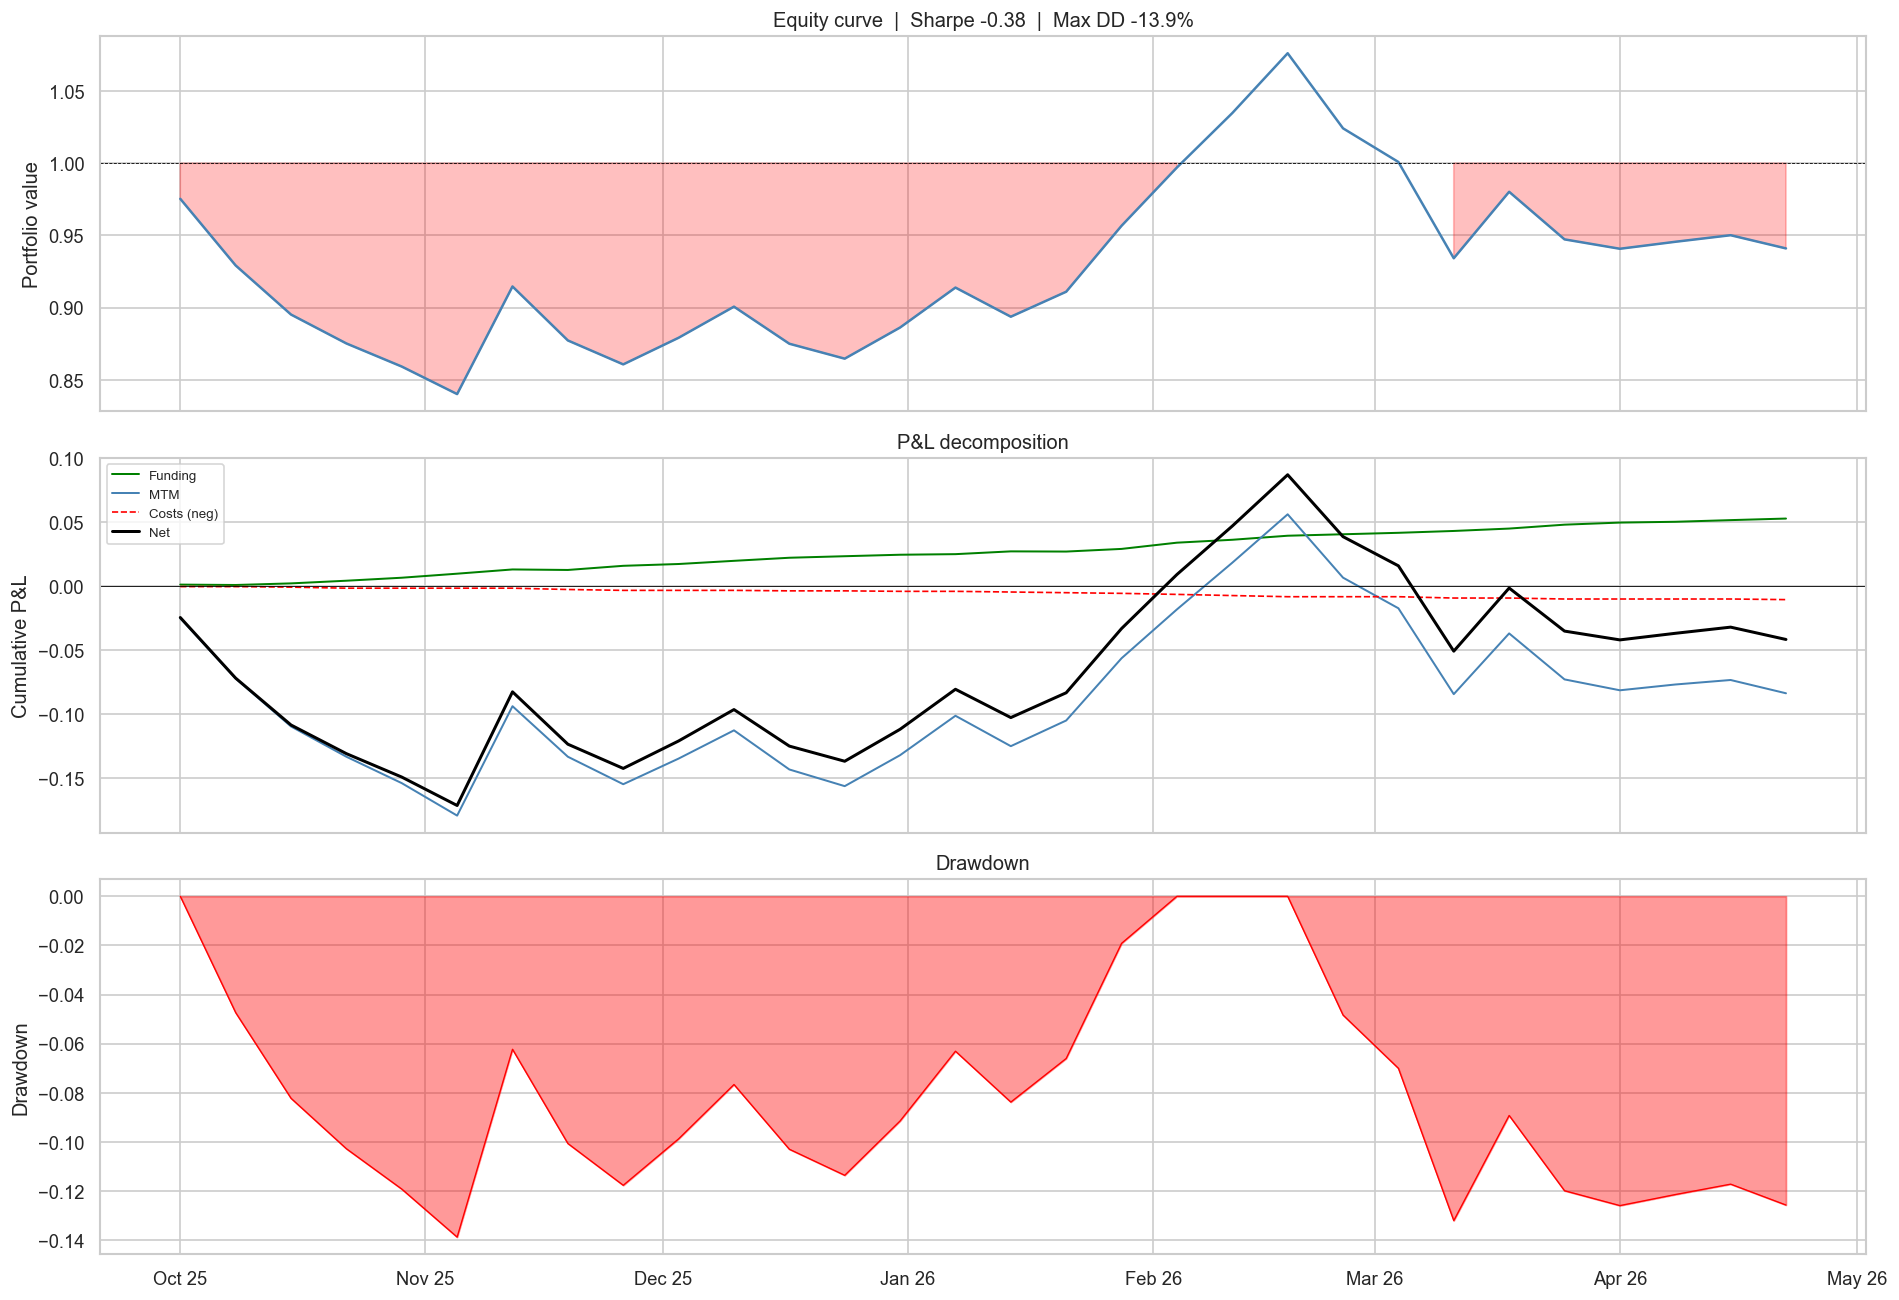

In [66]:
fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)

# Equity curve
axes[0].plot(equity.index, equity, color='steelblue', lw=1.5)
axes[0].axhline(1, color='black', lw=0.5, ls='--')
axes[0].fill_between(equity.index, equity, 1, where=(equity < 1), color='red', alpha=0.25)
axes[0].set_ylabel('Portfolio value')
axes[0].set_title(f'Equity curve  |  Sharpe {sharpe:.2f}  |  Max DD {max_dd:.1%}')

# Cumulative P&L decomposition
cum = pd.DataFrame({
    'Funding': results['funding_pnl'].cumsum(),
    'MTM':     results['mtm_pnl'].cumsum(),
    'Costs':   -results['cost'].cumsum(),
    'Net':     results['net_pnl'].cumsum(),
}, index=results.index)
axes[1].plot(cum['Funding'], color='green', lw=1.2, label='Funding')
axes[1].plot(cum['MTM'], color='steelblue', lw=1.2, label='MTM')
axes[1].plot(cum['Costs'], color='red', lw=1.0, ls='--', label='Costs (neg)')
axes[1].plot(cum['Net'], color='black', lw=1.8, label='Net')
axes[1].axhline(0, color='black', lw=0.5)
axes[1].set_ylabel('Cumulative P&L')
axes[1].set_title('P&L decomposition')
axes[1].legend(fontsize=8)

# Drawdown
axes[2].fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.4)
axes[2].plot(drawdown.index, drawdown, color='red', lw=0.8)
axes[2].set_ylabel('Drawdown')
axes[2].set_title('Drawdown')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))

plt.tight_layout()
plt.show()

## 6. Trade-Level Analysis

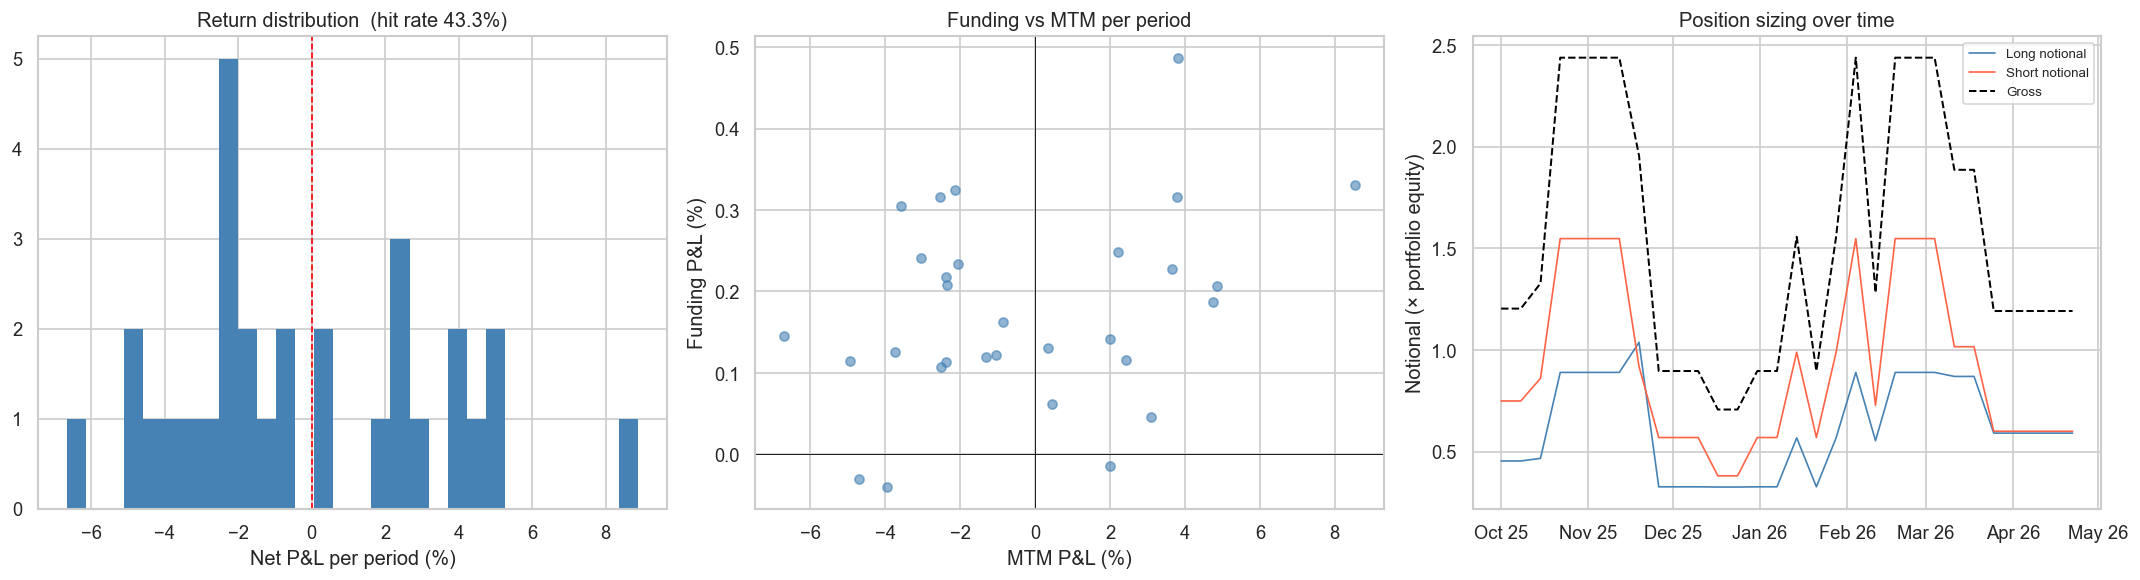

Most common pairs:
long_coin  short_coin
SOL        BTC           8
ZRO        BTC           6
SOL        LINK          5
ADA        BTC           2
APE        BTC           2
SOL        ETH           2
ZRO        ETH           2
BNB        BTC           1
SUI        BTC           1
XRP        BTC           1


In [67]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Return distribution
axes[0].hist(results['net_pnl'] * 100, bins=30, color='steelblue', edgecolor='none')
axes[0].axvline(0, color='red', lw=1, ls='--')
axes[0].set_xlabel('Net P&L per period (%)')
axes[0].set_title(f'Return distribution  (hit rate {hit_rate:.1%})')

# Funding vs MTM per period
axes[1].scatter(results['mtm_pnl'] * 100, results['funding_pnl'] * 100,
                alpha=0.6, color='steelblue', s=30)
axes[1].axhline(0, color='black', lw=0.5)
axes[1].axvline(0, color='black', lw=0.5)
axes[1].set_xlabel('MTM P&L (%)')
axes[1].set_ylabel('Funding P&L (%)')
axes[1].set_title('Funding vs MTM per period')

# Gross leverage over time
axes[2].plot(results.index, results['L'], color='steelblue', lw=1, label='Long notional')
axes[2].plot(results.index, results['S'], color='tomato',    lw=1, label='Short notional')
axes[2].plot(results.index, results['L'] + results['S'], color='black', lw=1.2, ls='--', label='Gross')
axes[2].set_ylabel('Notional (× portfolio equity)')
axes[2].set_title('Position sizing over time')
axes[2].legend(fontsize=8)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))

plt.tight_layout()
plt.show()

# Coin frequency table
pair_counts = results.groupby(['long_coin', 'short_coin']).size().sort_values(ascending=False)
print('Most common pairs:')
print(pair_counts.head(10).to_string())

## 7. Cost Sensitivity

Breakeven fee rate: -11.70 bps


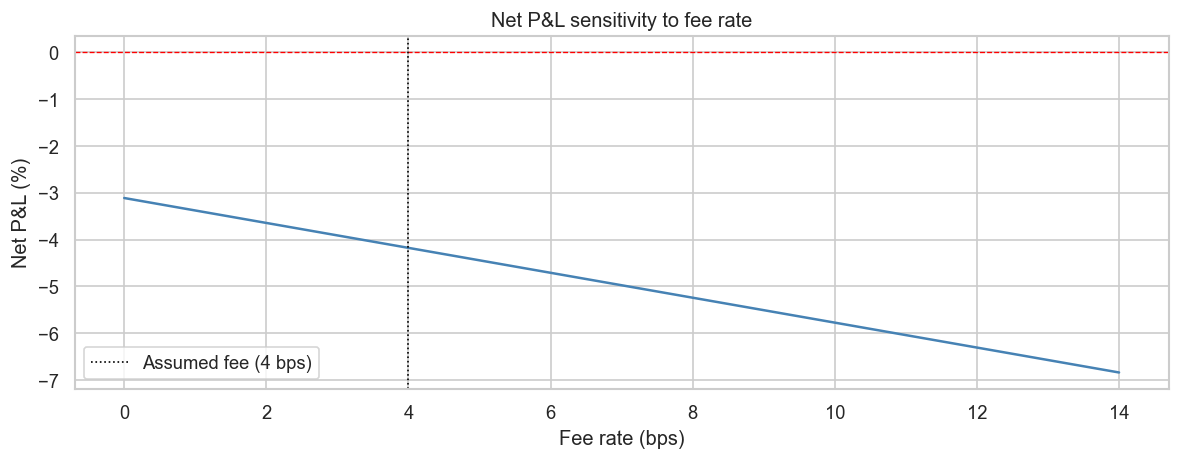

In [68]:
# How sensitive is net P&L to the assumed fee rate?
fee_range = np.arange(0, 0.0015, 0.0001)   # 0 to 15 bps
total_trades = results['cost'].sum() / TAKER_FEE  # total notional traded

gross_pnl = (results['funding_pnl'] + results['mtm_pnl']).sum()
net_at_fee = gross_pnl - fee_range * total_trades

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(fee_range * 1e4, net_at_fee * 100, color='steelblue', lw=1.5)
ax.axhline(0, color='red', lw=0.8, ls='--')
ax.axvline(TAKER_FEE * 1e4, color='black', lw=1, ls=':', label=f'Assumed fee ({TAKER_FEE*1e4:.0f} bps)')
ax.set_xlabel('Fee rate (bps)')
ax.set_ylabel('Net P&L (%)')
ax.set_title('Net P&L sensitivity to fee rate')
ax.legend()
breakeven_fee = gross_pnl / total_trades
print(f'Breakeven fee rate: {breakeven_fee*1e4:.2f} bps')
plt.tight_layout()
plt.show()

## 8. Beta Stability Check

Verify that in-sample betas (used for position sizing throughout the backtest) remained stable
over the OOS period. Material drift would impair beta neutralization and inflate realized market exposure.

      beta_insample  beta_oos     drift
DOGE       1.068458  0.869085 -0.199373
ZRO        1.012829  0.815171 -0.197658
TAO        1.085649  0.947021 -0.138628
SOL        1.011693  0.911305 -0.100388
ADA        1.012469  0.914043 -0.098426
ARB        1.069130  0.976581 -0.092549
LINK       0.996111  0.915473 -0.080637
AAVE       1.009826  0.929560 -0.080266
SUI        1.071696  1.021987 -0.049709
LDO        1.133107  1.083499 -0.049608
ETH        0.866189  0.828838 -0.037351
APE        0.959739  0.928128 -0.031611
XRP        0.764232  0.753908 -0.010324
BTC        0.581576  0.575916 -0.005660
BNB        0.514458  0.606804  0.092346

Mean absolute drift: 0.0843
Rank correlation in-sample vs OOS: 0.7821


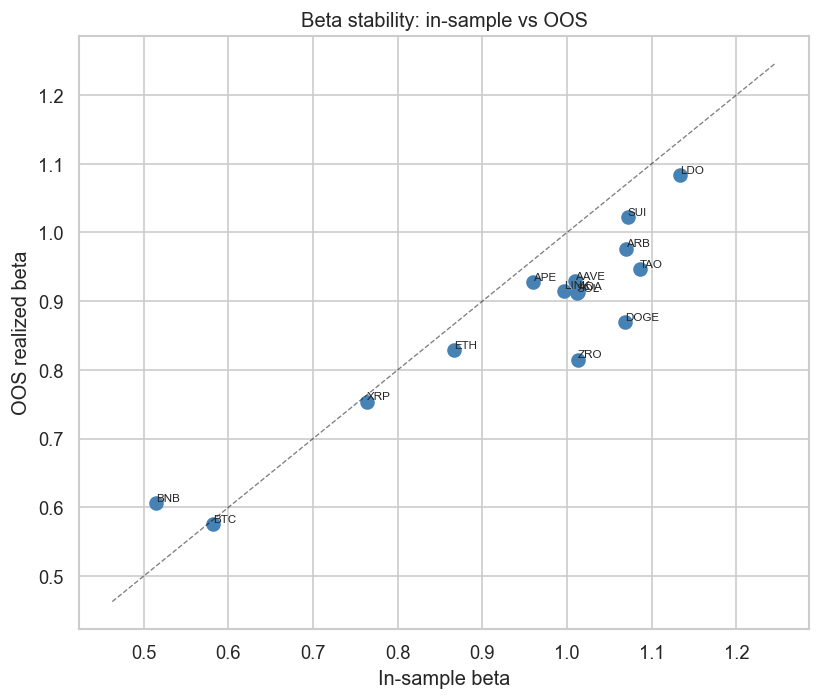

In [69]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

trio = ['BTC', 'ETH', 'SOL']
trio_available = [c for c in trio if c in prices_oos.columns]
trio_rets_oos = prices_oos[trio_available].pct_change().dropna()

scaler_oos = StandardScaler()
X_oos = scaler_oos.fit_transform(trio_rets_oos)
pca_oos = PCA(n_components=1).fit(X_oos)

# Sign-correct so PC1 loads positively on BTC
if pca_oos.components_[0, trio_available.index('BTC')] < 0:
    pca_oos.components_[0] *= -1

btc_std_oos = trio_rets_oos['BTC'].std()
market_oos = pca_oos.transform(X_oos)[:, 0] * btc_std_oos
market_oos = pd.Series(market_oos, index=trio_rets_oos.index)

# Regress each coin's OOS returns on PC1
oos_rets = prices_oos[[c for c in betas.index if c in prices_oos.columns]].pct_change().dropna()

beta_oos = {}
for coin in oos_rets.columns:
    common_idx = oos_rets.index.intersection(market_oos.index)
    y = oos_rets.loc[common_idx, coin].values.reshape(-1, 1)
    x = market_oos.loc[common_idx].values.reshape(-1, 1)
    beta_oos[coin] = LinearRegression().fit(x, y).coef_[0, 0]

beta_compare = pd.DataFrame({
    'beta_insample': betas['beta'],
    'beta_oos':      pd.Series(beta_oos),
}).dropna()
beta_compare['drift'] = beta_compare['beta_oos'] - beta_compare['beta_insample']

print(beta_compare.sort_values('drift').to_string())
print(f"\nMean absolute drift: {beta_compare['drift'].abs().mean():.4f}")
print(f"Rank correlation in-sample vs OOS: {beta_compare['beta_insample'].corr(beta_compare['beta_oos'], method='spearman'):.4f}")

# Scatter: in-sample vs OOS betas
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(beta_compare['beta_insample'], beta_compare['beta_oos'], color='steelblue', s=60)
for coin, row in beta_compare.iterrows():
    ax.annotate(coin, (row['beta_insample'], row['beta_oos']),
                fontsize=7, ha='left', va='bottom')
lims = [beta_compare[['beta_insample', 'beta_oos']].min().min() * 0.9,
        beta_compare[['beta_insample', 'beta_oos']].max().max() * 1.1]
ax.plot(lims, lims, 'k--', lw=0.8, alpha=0.5)
ax.set_xlabel('In-sample beta')
ax.set_ylabel('OOS realized beta')
ax.set_title('Beta stability: in-sample vs OOS')
plt.tight_layout()
plt.show()